In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import style
style.use("ggplot")
import warnings
warnings.filterwarnings("ignore")

In [2]:
#import dataset
df=pd.read_csv("student_info.csv")
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [3]:
df.shape

(200, 2)

In [4]:
#check missing values
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [5]:
#handle missing values.
df=df.fillna(df.mean())
df.isnull().sum()

study_hours      0
student_marks    0
dtype: int64

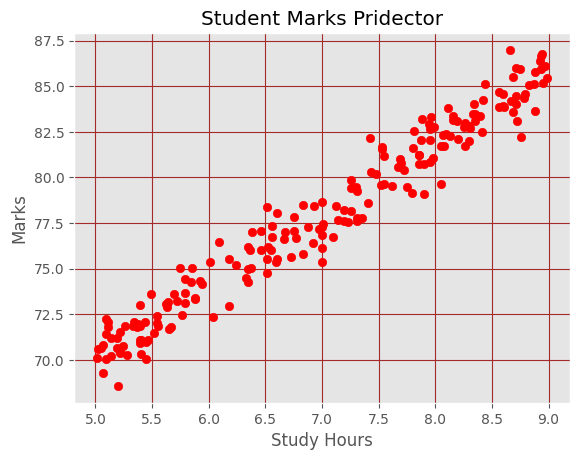

In [6]:
#visualization of data
plt.scatter(x=df.study_hours, y=df.student_marks , color='red')
plt.title("Student Marks Pridector")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.grid(color='brown')
plt.show()

In [7]:
#seperate dataset into independent and dependent variables
X=df.drop("student_marks",axis=1)
X.head(3)

,study_hours
0,6.830000
1,6.560000
2,6.995949


In [8]:
#seperate dataset into independent and dependent variables
y=df.drop("study_hours",axis=1)
y.head(3)

,student_marks
0,78.50
1,76.74
2,78.68


In [9]:
#split dataset into training and testing dataset.
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [10]:
X_train.shape

(160, 1)

In [11]:
y_train.shape

(160, 1)

In [12]:
X_test.shape

(40, 1)

In [13]:
y_test.shape

(40, 1)

In [14]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
#Test the model
res=model.predict([[0]])[0][0].round(2)
print(f"Expected Result={res}")

Expected Result=50.5


In [18]:
sh=float(input("Enter study hours 0-12 : "))
if sh>=0 and sh<=12:
    res=model.predict([[sh]])[0][0].round(2)
    print(f"Expected Result={res}")
else:
    print("Invalid study Hours")

Enter study hours 0-12 :  3


Expected Result=62.27
